## figure for flat control

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
import networkx as nx
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from flat_model import *
from hier_model import *


In [2]:
# for dev 
%load_ext autoreload
%autoreload 2

In [3]:

def CC_exp(nTrials, acq_frac=0.4, seed=None):
    """
    Classic acquisition followed by extinction with 50% reinforcement of CS+ during acquisition.

    Returns features: [CS+, CS-, shock]
    """
    if seed is not None:
        np.random.seed(seed)
    nAcq = int(nTrials * acq_frac)
    nExt = nTrials - nAcq
    is_cs_plus = np.random.rand(nAcq) < 0.5
    acq_cs_plus = is_cs_plus.astype(int)
    acq_cs_minus = (~is_cs_plus).astype(int)
    is_reinforced = np.random.rand(nAcq) < 0.5
    acq_shock = (acq_cs_plus & is_reinforced).astype(int)
    is_ext_cs_plus = np.random.rand(nExt) < 0.5
    ext_cs_plus = is_ext_cs_plus.astype(int)
    ext_cs_minus = (~is_ext_cs_plus).astype(int)
    ext_shock = np.zeros(nExt, dtype=int)
    cs_plus = np.concatenate([acq_cs_plus, ext_cs_plus])
    cs_minus = np.concatenate([acq_cs_minus, ext_cs_minus])
    shock = np.concatenate([acq_shock, ext_shock])
    f = np.vstack([cs_plus, cs_minus, shock])
    return f, 3, nExt


In [ ]:
def run_inference_simulations_with_stats(
    nParticipants, 
    expType, 
    nExt, 
    nTrials, 
    param_set, 
    model_type="hierarchical", 
    outcome_idx=2, 
    depth=None, 
    rando = 13,
    n_bootstrap=1000,
    confidence_level=95
):
    """
    Run multiple simulated 'participants' through selected inference loop
    WITH COMPREHENSIVE STATISTICAL ANALYSIS.

    based on Hartley 2014 set up and Aitsahalia 2022 thesis

    Parameters
    ----------
    nParticipants : int
        Number of simulated subjects.
    expType : str
        Experiment type: one of {'cued_reversal','extinction','extinction_recovery','recurring_context'}
    nExt : int
        Used as block length or phase length for certain tasks.
    nTrials : int
        Total number of trials.
    param_set : tuple
        (regime, alpha[, beta, eta]) parameters for the inference.
    model_type : str
        'hierarchical' (default) or 'one_layer' to select inference model.
    outcome_idx : int
        Index of the outcome variable to analyze (default is 2).
    depth : int or None
        Maximum tree depth for hierarchical model.
    rando : int
        Random seed base.
    n_bootstrap : int
        Number of bootstrap samples for confidence intervals.
    confidence_level : int
        Confidence level for intervals (default: 95).

    Returns
    -------
    results : dict
        Comprehensive results including:
        - Raw data (r_plus_all, r_minus_all)
        - Summary statistics (means, SEM, CI)
        - Statistical tests
        - Metadata
    """
    
    if rando is None:
        rando = np.random.randint(0, 50)
    
    regime = param_set[0]
    alpha = param_set[1]
    beta = param_set[2] if len(param_set) > 2 else None
    eta = param_set[3] if len(param_set) > 3 else None
    nt = nTrials
    
    # Storage for all participants
    r_plus_all = []
    r_minus_all = []
    cEst_all = []
    cEst_levels_all = []
    paths_all = []
    n_clusters_all = []
    tree_depths_all = []
    convergence_trials_all = []
    
    # Run simulations
    print(f"\n{'='*70}")
    print(f"Running {nParticipants} participants: {model_type} model, {expType}")
    print(f"Parameters: regime={regime}, alpha={alpha}")
    print(f"{'='*70}\n")
    
    
    for p in range(nParticipants):
        print(f"Participant {p+1}/{nParticipants}", end="\r")

        # Generate experiment
        if expType == 'extinction':
            f_raw, numfeat, n_ext = CC_exp(nt, acq_frac=0.4, seed=rando+p)
            n_ext = nt - n_ext
        else:
            raise ValueError(f"Unsupported expType: {expType}")


        f = f_raw[:numfeat, :nt]
        print(f"DEBUG: Feature matrix shape: {f.shape}")
        print(f"DEBUG: CS+ trials: {np.sum(f[0, :] == 1)}")
        print(f"DEBUG: CS- trials: {np.sum(f[1, :] == 1)}")
        print(f"DEBUG: Shock trials: {np.sum(f[2, :] == 1)}")
        print(f"DEBUG: First 10 trials:\n{f[:, :10]}")
        
        # Extract responses
        csplus_mask = (f[0, :] == 1)
        csminus_mask = (f[1, :] == 1)
        
        print(f"DEBUG: CS+ mask sum: {np.sum(csplus_mask)}")
        print(f"DEBUG: CS- mask sum: {np.sum(csminus_mask)}")
    # In run_inference_simulations_with_stats:

        if model_type == "hierarchical":
            particles, cEst, rEst, phiEst, cEst_levels, paths, weights = full_hier_inference_loop(
                nTrials=nt,
                nParticles=200,
                nFeatures=numfeat,
                omega=regime,
                alpha=alpha,
                f=f,
                max_depth=depth if depth is not None else 10,
                random_seed=rando+p,
                outcome_idx=outcome_idx
            )
            
            tree_depth = compute_tree_depth(paths)
            
        elif model_type == "one_layer":
            particles, cEst, rEst, phiEst = one_layer_inference_loop(
                nTrials=nt,
                nParticles=200,
                nFeatures=numfeat,
                regime=regime,
                alpha=alpha,
                f=f,
                outcome_idx_per_trial=[outcome_idx]*nt,
                feedback_mask=None,
                include_outcome_in_weight=True,
                length_normalize=False,
                tau=1.0,
                random_seed=rando+p
            )
            cEst_levels = None
            paths = None
            tree_depth = 1
        else:
            raise ValueError("model_type must be 'hierarchical' or 'one_layer'")

        # UNIFIED CLUSTER COUNTING (works for both models)
        trial_assignment = np.argmax(cEst, axis=0)
        n_clusters = len(np.unique(trial_assignment))

        print(f"DEBUG - cEst shape: {cEst.shape}")
        print(f"DEBUG - trial_assignment (first 10): {trial_assignment[:10]}")
        print(f"DEBUG - Unique clusters: {np.unique(trial_assignment)}")
        print(f"DEBUG - n_clusters: {n_clusters}")

        # Extract CS+/CS- responses
        csplus_mask = (f[0, :] == 1)
        csminus_mask = (f[1, :] == 1)
        r_plus = np.where(csplus_mask, rEst, np.nan)
        r_minus = np.where(csminus_mask, rEst, np.nan)

        print(f"DEBUG: rEst shape: {rEst.shape}")
        print(f"DEBUG: rEst range: [{np.nanmin(rEst)}, {np.nanmax(rEst)}]")
        
        r_plus = np.where(csplus_mask, rEst, np.nan)
        r_minus = np.where(csminus_mask, rEst, np.nan)
        
        print(f"DEBUG: r_plus non-nan: {np.sum(~np.isnan(r_plus))}")
        print(f"DEBUG: r_minus non-nan: {np.sum(~np.isnan(r_minus))}")

        # Store results
        r_plus_all.append(r_plus)
        r_minus_all.append(r_minus)
        cEst_all.append(cEst)
        cEst_levels_all.append(cEst_levels)
        paths_all.append(paths)
        n_clusters_all.append(n_clusters)
        tree_depths_all.append(tree_depth)
        
        # Compute convergence trial (when response stabilizes)
        conv_trial = compute_convergence_trial(r_plus, threshold=0.05)
        convergence_trials_all.append(conv_trial)
    
    print(f"\nCompleted {nParticipants} participants                    ")
    
    # Compute comprehensive statistics
    stats = compute_learning_statistics(
        r_plus_all=r_plus_all,
        r_minus_all=r_minus_all,
        n_ext=n_ext,
        nTrials=nt,
        n_bootstrap=n_bootstrap,
        confidence_level=confidence_level
    )
    
    # Add additional metrics
    stats['n_clusters'] = {
        'mean': np.mean(n_clusters_all),
        'std': np.std(n_clusters_all, ddof=1),
        'median': np.median(n_clusters_all),
        'range': (np.min(n_clusters_all), np.max(n_clusters_all))
    }
    
    stats['tree_depth'] = {
        'mean': np.mean(tree_depths_all),
        'std': np.std(tree_depths_all, ddof=1),
        'median': np.median(tree_depths_all)
    }
    
    stats['convergence_trials'] = {
        'mean': np.mean(convergence_trials_all),
        'std': np.std(convergence_trials_all, ddof=1),
        'median': np.median(convergence_trials_all)
    }
    
    # Package results
    results = {
        'raw_data': {
            'r_plus_all': r_plus_all,
            'r_minus_all': r_minus_all,
            'cEst_all': cEst_all,
            'cEst_levels_all': cEst_levels_all,
            'paths_all': paths_all,
            'f': f,
            'n_ext': n_ext
        },
        'statistics': stats,
        'metadata': {
            'nParticipants': nParticipants,
            'expType': expType,
            'nTrials': nt,
            'model_type': model_type,
            'param_set': param_set,
            'regime': regime,
            'alpha': alpha,
            'beta': beta,
            'eta': eta
        }
    }
    
    # Print summary
    print_learning_summary(stats, model_type)
    
    return results

def compute_learning_statistics(r_plus_all, r_minus_all, n_ext, nTrials, 
                                 n_bootstrap=1000, confidence_level=95):
    """
    Compute comprehensive statistics for learning curves.
    FIXED VERSION for extinction tasks.
    """
    
    from scipy import stats as scipy_stats
    
    nParticipants = len(r_plus_all)
    
    # Initialize statistics dictionary
    stats = {
        'cs_plus': {},
        'cs_minus': {},
        'discrimination': {},
        'acquisition': {},
        'extinction': {},
        'n_clusters': {},
        'tree_depth': {},
        'convergence_trials': {}
    }
    
    # ============================================================
    # EXTRACT VALID CS+ AND CS- VALUES (CRITICAL FIX!)
    # ============================================================
    
    # For each participant, extract their CS+ and CS- trials separately
    cs_plus_acq_all = []  # CS+ during acquisition
    cs_minus_acq_all = []  # CS- during acquisition
    cs_plus_ext_all = []  # CS+ during extinction
    
    for p in range(nParticipants):
        r_plus = r_plus_all[p]
        r_minus = r_minus_all[p]
        
        # Acquisition phase (0 to n_ext)
        acq_plus = r_plus[:n_ext]
        acq_minus = r_minus[:n_ext]
        
        # Extract only valid (non-NaN) values
        valid_acq_plus = acq_plus[~np.isnan(acq_plus)]
        valid_acq_minus = acq_minus[~np.isnan(acq_minus)]
        
        cs_plus_acq_all.append(valid_acq_plus)
        cs_minus_acq_all.append(valid_acq_minus)
        
        # Extinction phase (n_ext to end)
        ext_plus = r_plus[n_ext:]
        valid_ext_plus = ext_plus[~np.isnan(ext_plus)]
        
        cs_plus_ext_all.append(valid_ext_plus)
    
    # ============================================================
    # ACQUISITION PHASE STATISTICS
    # ============================================================
    
    # Compute mean for each participant during final 20% of acquisition
    acq_plus_final = np.array([
        np.mean(x[int(0.8*len(x)):]) if len(x) > 0 else np.nan 
        for x in cs_plus_acq_all
    ])
    
    acq_minus_final = np.array([
        np.mean(x[int(0.8*len(x)):]) if len(x) > 0 else np.nan 
        for x in cs_minus_acq_all
    ])
    
    # Remove NaN participants
    valid_plus = acq_plus_final[~np.isnan(acq_plus_final)]
    valid_minus = acq_minus_final[~np.isnan(acq_minus_final)]
    
    # CS+ statistics
    if len(valid_plus) > 0:
        stats['acquisition']['cs_plus_final_mean'] = np.mean(valid_plus)
        stats['acquisition']['cs_plus_final_std'] = np.std(valid_plus, ddof=1) if len(valid_plus) > 1 else 0.0
        stats['acquisition']['cs_plus_final_ci'] = bootstrap_ci(valid_plus, n_bootstrap, confidence_level)
    else:
        stats['acquisition']['cs_plus_final_mean'] = np.nan
        stats['acquisition']['cs_plus_final_std'] = np.nan
        stats['acquisition']['cs_plus_final_ci'] = (np.nan, np.nan)
    
    # CS- statistics
    if len(valid_minus) > 0:
        stats['acquisition']['cs_minus_final_mean'] = np.mean(valid_minus)
        stats['acquisition']['cs_minus_final_std'] = np.std(valid_minus, ddof=1) if len(valid_minus) > 1 else 0.0
        stats['acquisition']['cs_minus_final_ci'] = bootstrap_ci(valid_minus, n_bootstrap, confidence_level)
    else:
        stats['acquisition']['cs_minus_final_mean'] = np.nan
        stats['acquisition']['cs_minus_final_std'] = np.nan
        stats['acquisition']['cs_minus_final_ci'] = (np.nan, np.nan)
    
    # Discrimination (only for participants with both CS+ and CS-)
    both_valid = ~np.isnan(acq_plus_final) & ~np.isnan(acq_minus_final)
    
    if np.sum(both_valid) > 0:
        discrimination = acq_plus_final[both_valid] - acq_minus_final[both_valid]
        
        stats['acquisition']['discrimination_mean'] = np.mean(discrimination)
        stats['acquisition']['discrimination_std'] = np.std(discrimination, ddof=1) if len(discrimination) > 1 else 0.0
        stats['acquisition']['discrimination_ci'] = bootstrap_ci(discrimination, n_bootstrap, confidence_level)
        
        # Paired t-test
        if len(discrimination) > 1:
            t_stat, p_val = scipy_stats.ttest_rel(
                acq_plus_final[both_valid], 
                acq_minus_final[both_valid]
            )
            stats['acquisition']['discrimination_ttest'] = {
                't_statistic': t_stat,
                'p_value': p_val,
                'significant': p_val < 0.05,
                'cohens_d': np.mean(discrimination) / np.std(discrimination, ddof=1)
            }
        else:
            stats['acquisition']['discrimination_ttest'] = {
                't_statistic': np.nan,
                'p_value': np.nan,
                'significant': False,
                'cohens_d': np.nan
            }
    else:
        stats['acquisition']['discrimination_mean'] = np.nan
        stats['acquisition']['discrimination_std'] = np.nan
        stats['acquisition']['discrimination_ci'] = (np.nan, np.nan)
        stats['acquisition']['discrimination_ttest'] = {
            't_statistic': np.nan,
            'p_value': np.nan,
            'significant': False,
            'cohens_d': np.nan
        }
    
    # ============================================================
    # EXTINCTION PHASE STATISTICS
    # ============================================================
    
    # Final 20% of extinction
    ext_plus_final = np.array([
        np.mean(x[int(0.8*len(x)):]) if len(x) > 0 else np.nan 
        for x in cs_plus_ext_all
    ])
    
    valid_ext = ext_plus_final[~np.isnan(ext_plus_final)]
    
    if len(valid_ext) > 0:
        stats['extinction']['cs_plus_final_mean'] = np.mean(valid_ext)
        stats['extinction']['cs_plus_final_std'] = np.std(valid_ext, ddof=1) if len(valid_ext) > 1 else 0.0
        stats['extinction']['cs_plus_final_ci'] = bootstrap_ci(valid_ext, n_bootstrap, confidence_level)
    else:
        stats['extinction']['cs_plus_final_mean'] = np.nan
        stats['extinction']['cs_plus_final_std'] = np.nan
        stats['extinction']['cs_plus_final_ci'] = (np.nan, np.nan)
    
    # Extinction reduction (from acquisition to extinction)
    both_phases_valid = ~np.isnan(acq_plus_final) & ~np.isnan(ext_plus_final)
    
    if np.sum(both_phases_valid) > 0:
        reduction = acq_plus_final[both_phases_valid] - ext_plus_final[both_phases_valid]
        
        stats['extinction']['reduction_mean'] = np.mean(reduction)
        stats['extinction']['reduction_std'] = np.std(reduction, ddof=1) if len(reduction) > 1 else 0.0
        stats['extinction']['reduction_ci'] = bootstrap_ci(reduction, n_bootstrap, confidence_level)
        
        # Paired t-test
        if len(reduction) > 1:
            t_stat, p_val = scipy_stats.ttest_rel(
                acq_plus_final[both_phases_valid], 
                ext_plus_final[both_phases_valid]
            )
            stats['extinction']['reduction_ttest'] = {
                't_statistic': t_stat,
                'p_value': p_val,
                'significant': p_val < 0.05,
                'cohens_d': np.mean(reduction) / np.std(reduction, ddof=1) if np.std(reduction, ddof=1) > 0 else np.nan
            }
        else:
            stats['extinction']['reduction_ttest'] = {
                't_statistic': np.nan,
                'p_value': np.nan,
                'significant': False,
                'cohens_d': np.nan
            }
    else:
        stats['extinction']['reduction_mean'] = np.nan
        stats['extinction']['reduction_std'] = np.nan
        stats['extinction']['reduction_ci'] = (np.nan, np.nan)
        stats['extinction']['reduction_ttest'] = {
            't_statistic': np.nan,
            'p_value': np.nan,
            'significant': False,
            'cohens_d': np.nan
        }
    
    # ============================================================
    # TRIAL-BY-TRIAL CURVES (for plotting - compute from all data)
    # ============================================================
    
    # Create trial-by-trial averages by only averaging valid values at each trial
    max_trials = max([len(r_plus_all[p]) for p in range(nParticipants)])
    
    cs_plus_curve = np.full(max_trials, np.nan)
    cs_minus_curve = np.full(max_trials, np.nan)
    cs_plus_sem = np.full(max_trials, np.nan)
    cs_minus_sem = np.full(max_trials, np.nan)
    
    for t in range(max_trials):
        # CS+ at this trial
        plus_values = [r_plus_all[p][t] for p in range(nParticipants) if t < len(r_plus_all[p])]
        plus_valid = [v for v in plus_values if not np.isnan(v)]
        
        if len(plus_valid) > 0:
            cs_plus_curve[t] = np.mean(plus_valid)
            if len(plus_valid) > 1:
                cs_plus_sem[t] = np.std(plus_valid, ddof=1) / np.sqrt(len(plus_valid))
        
        # CS- at this trial
        minus_values = [r_minus_all[p][t] for p in range(nParticipants) if t < len(r_minus_all[p])]
        minus_valid = [v for v in minus_values if not np.isnan(v)]
        
        if len(minus_valid) > 0:
            cs_minus_curve[t] = np.mean(minus_valid)
            if len(minus_valid) > 1:
                cs_minus_sem[t] = np.std(minus_valid, ddof=1) / np.sqrt(len(minus_valid))
    
    stats['cs_plus']['mean'] = cs_plus_curve
    stats['cs_plus']['sem'] = cs_plus_sem
    stats['cs_minus']['mean'] = cs_minus_curve
    stats['cs_minus']['sem'] = cs_minus_sem
    
    # Discrimination curve
    stats['discrimination']['mean'] = cs_plus_curve - cs_minus_curve
    
    # ============================================================
    # LEARNING RATES
    # ============================================================
    
    # Fit exponential to acquisition
    acq_learning_rates = []
    for p in range(nParticipants):
        try:
            if len(cs_plus_acq_all[p]) > 3:
                rate = fit_exponential_learning(cs_plus_acq_all[p], target_value=0.5)
                acq_learning_rates.append(rate)
        except:
            pass
    
    if len(acq_learning_rates) > 0:
        stats['acquisition']['learning_rate_mean'] = np.mean(acq_learning_rates)
        stats['acquisition']['learning_rate_std'] = np.std(acq_learning_rates, ddof=1) if len(acq_learning_rates) > 1 else 0.0
    
    # Fit exponential to extinction
    ext_learning_rates = []
    for p in range(nParticipants):
        try:
            if len(cs_plus_ext_all[p]) > 3:
                rate = fit_exponential_learning(cs_plus_ext_all[p], target_value=0.0)
                ext_learning_rates.append(rate)
        except:
            pass
    
    if len(ext_learning_rates) > 0:
        stats['extinction']['learning_rate_mean'] = np.mean(ext_learning_rates)
        stats['extinction']['learning_rate_std'] = np.std(ext_learning_rates, ddof=1) if len(ext_learning_rates) > 1 else 0.0
    
    return stats
def bootstrap_ci(data, n_bootstrap=1000, confidence_level=95):
    """Compute bootstrap confidence interval."""
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    alpha = (100 - confidence_level) / 2
    lower = np.percentile(bootstrap_means, alpha)
    upper = np.percentile(bootstrap_means, 100 - alpha)
    return lower, upper

def compute_tree_depth(paths):
    """
    Compute maximum depth of tree from paths array.
    
    Parameters
    ----------
    paths : array (n_particles, n_trials, max_depth)
        Paths through tree
        
    Returns
    -------
    max_depth : int
        Maximum depth observed
    """
    if paths is None:
        return 1
    
    max_depth = 0
    n_particles, n_trials, depth_dim = paths.shape
    
    for p in range(n_particles):
        for t in range(n_trials):
            path = paths[p, t, :]  # Path for particle p at trial t
            depth = np.sum(path >= 0)  # Count non-negative nodes in path
            max_depth = max(max_depth, depth)
    
    return max_depth


def compute_convergence_trial(responses, threshold=0.05, window=5):
    """
    Find trial where response stabilizes (stops changing by more than threshold).
    
    Parameters
    ----------
    responses : array
        Trial-by-trial responses
    threshold : float
        Threshold for change detection
    window : int
        Number of consecutive trials that must be stable
        
    Returns
    -------
    conv_trial : int
        Trial index of convergence (or len(responses) if never converges)
    """
    valid_responses = responses[~np.isnan(responses)]
    if len(valid_responses) < window + 1:
        return len(responses)
    
    for i in range(len(valid_responses) - window):
        changes = np.abs(np.diff(valid_responses[i:i+window+1]))
        if np.all(changes < threshold):
            return i
    
    return len(responses)


def fit_exponential_learning(responses, target_value=0.5):
    """
    Fit exponential learning curve: y = target + (y0 - target) * exp(-rate * t)
    
    Returns learning rate parameter.
    """
    from scipy.optimize import curve_fit
    
    valid_responses = responses[~np.isnan(responses)]
    if len(valid_responses) < 3:
        return np.nan
    
    t = np.arange(len(valid_responses))
    
    def exp_func(t, rate, y0):
        return target_value + (y0 - target_value) * np.exp(-rate * t)
    
    try:
        popt, _ = curve_fit(exp_func, t, valid_responses, p0=[0.1, valid_responses[0]], maxfev=5000)
        return popt[0]  # learning rate
    except:
        return np.nan


def print_learning_summary(stats, model_type):
    """Print formatted summary of learning statistics."""
    
    print(f"\n{'='*70}")
    print(f"LEARNING STATISTICS SUMMARY: {model_type.upper()} MODEL")
    print(f"{'='*70}")
    
    # Acquisition phase
    print(f"\n{'─'*70}")
    print("ACQUISITION PHASE (Final 20% of trials)")
    print(f"{'─'*70}")
    
    acq = stats['acquisition']
    print(f"  CS+ Response:")
    print(f"    Mean: {acq['cs_plus_final_mean']:.3f} ± {acq['cs_plus_final_std']:.3f}")
    print(f"    95% CI: [{acq['cs_plus_final_ci'][0]:.3f}, {acq['cs_plus_final_ci'][1]:.3f}]")
    
    print(f"\n  CS- Response:")
    print(f"    Mean: {acq['cs_minus_final_mean']:.3f} ± {acq['cs_minus_final_std']:.3f}")
    print(f"    95% CI: [{acq['cs_minus_final_ci'][0]:.3f}, {acq['cs_minus_final_ci'][1]:.3f}]")
    
    print(f"\n  Discrimination (CS+ - CS-):")
    print(f"    Mean: {acq['discrimination_mean']:.3f} ± {acq['discrimination_std']:.3f}")
    print(f"    95% CI: [{acq['discrimination_ci'][0]:.3f}, {acq['discrimination_ci'][1]:.3f}]")
    
    disc_test = acq['discrimination_ttest']
    sig_str = "***" if disc_test['p_value'] < 0.001 else "**" if disc_test['p_value'] < 0.01 else "*" if disc_test['p_value'] < 0.05 else "n.s."
    print(f"    t({disc_test['t_statistic']:.2f}) = {disc_test['p_value']:.4f} {sig_str}")
    print(f"    Cohen's d = {disc_test['cohens_d']:.3f}")
    
    if 'learning_rate_mean' in acq:
        print(f"\n  Learning Rate: {acq['learning_rate_mean']:.4f} ± {acq['learning_rate_std']:.4f}")
    
    # Extinction phase
    print(f"\n{'─'*70}")
    print("EXTINCTION PHASE (Final 20% of trials)")
    print(f"{'─'*70}")
    
    ext = stats['extinction']
    print(f"  CS+ Response:")
    print(f"    Mean: {ext['cs_plus_final_mean']:.3f} ± {ext['cs_plus_final_std']:.3f}")
    print(f"    95% CI: [{ext['cs_plus_final_ci'][0]:.3f}, {ext['cs_plus_final_ci'][1]:.3f}]")
    
    print(f"\n  Extinction (Reduction from Acquisition):")
    print(f"    Mean: {ext['reduction_mean']:.3f} ± {ext['reduction_std']:.3f}")
    print(f"    95% CI: [{ext['reduction_ci'][0]:.3f}, {ext['reduction_ci'][1]:.3f}]")
    
    ext_test = ext['reduction_ttest']
    sig_str = "***" if ext_test['p_value'] < 0.001 else "**" if ext_test['p_value'] < 0.01 else "*" if ext_test['p_value'] < 0.05 else "n.s."
    print(f"    t({ext_test['t_statistic']:.2f}) = {ext_test['p_value']:.4f} {sig_str}")
    print(f"    Cohen's d = {ext_test['cohens_d']:.3f}")
    
    if 'learning_rate_mean' in ext:
        print(f"\n  Extinction Rate: {ext['learning_rate_mean']:.4f} ± {ext['learning_rate_std']:.4f}")
    
    # Model complexity
    if 'n_clusters' in stats:
        print(f"\n{'─'*70}")
        print("MODEL COMPLEXITY")
        print(f"{'─'*70}")
        
        nc = stats['n_clusters']
        print(f"  Number of Clusters:")
        print(f"    Mean: {nc['mean']:.2f} ± {nc['std']:.2f}")
        print(f"    Median: {nc['median']:.0f}")
        print(f"    Range: [{nc['range'][0]:.0f}, {nc['range'][1]:.0f}]")
        
        if 'tree_depth' in stats:
            td = stats['tree_depth']
            print(f"\n  Tree Depth:")
            print(f"    Mean: {td['mean']:.2f} ± {td['std']:.2f}")
            print(f"    Median: {td['median']:.0f}")
        
        if 'convergence_trials' in stats:
            ct = stats['convergence_trials']
            print(f"\n  Convergence Trial:")
            print(f"    Mean: {ct['mean']:.1f} ± {ct['std']:.1f}")
            print(f"    Median: {ct['median']:.0f}")
    
    print(f"\n{'='*70}\n")

def compare_models_statistically(results_flat, results_hier):
    """
    Compare flat vs hierarchical models statistically.
    FIXED VERSION.
    """
    
    from scipy import stats as scipy_stats
    
    comparison = {}
    
    # Get raw data
    flat_r_plus_all = results_flat['raw_data']['r_plus_all']
    hier_r_plus_all = results_hier['raw_data']['r_plus_all']
    n_ext = results_flat['raw_data']['n_ext']
    
    nParticipants = len(flat_r_plus_all)
    
    # ============================================================
    # ACQUISITION COMPARISON
    # ============================================================
    
    # Compute individual participant final acquisition scores
    flat_acq_indiv = []
    hier_acq_indiv = []
    
    for p in range(nParticipants):
        # Flat model
        r_plus_flat = flat_r_plus_all[p]
        acq_plus_flat = r_plus_flat[:n_ext]
        valid_acq_flat = acq_plus_flat[~np.isnan(acq_plus_flat)]
        
        if len(valid_acq_flat) > 0:
            acq_final_flat = np.mean(valid_acq_flat[int(0.8*len(valid_acq_flat)):])
            flat_acq_indiv.append(acq_final_flat)
        
        # Hierarchical model
        r_plus_hier = hier_r_plus_all[p]
        acq_plus_hier = r_plus_hier[:n_ext]
        valid_acq_hier = acq_plus_hier[~np.isnan(acq_plus_hier)]
        
        if len(valid_acq_hier) > 0:
            acq_final_hier = np.mean(valid_acq_hier[int(0.8*len(valid_acq_hier)):])
            hier_acq_indiv.append(acq_final_hier)
    
    flat_acq_indiv = np.array(flat_acq_indiv)
    hier_acq_indiv = np.array(hier_acq_indiv)
    
    # Independent samples t-test
    if len(flat_acq_indiv) > 0 and len(hier_acq_indiv) > 0:
        t_stat_acq, p_val_acq = scipy_stats.ttest_ind(flat_acq_indiv, hier_acq_indiv)
        
        comparison['acquisition'] = {
            'flat_mean': np.mean(flat_acq_indiv),
            'hier_mean': np.mean(hier_acq_indiv),
            'difference': np.mean(hier_acq_indiv) - np.mean(flat_acq_indiv),
            't_statistic': t_stat_acq,
            'p_value': p_val_acq,
            'significant': p_val_acq < 0.05,
            'cohens_d': (np.mean(hier_acq_indiv) - np.mean(flat_acq_indiv)) / np.sqrt((np.var(flat_acq_indiv) + np.var(hier_acq_indiv)) / 2)
        }
    
    # ============================================================
    # EXTINCTION COMPARISON 
    # ============================================================
    
    flat_ext_indiv = []
    hier_ext_indiv = []
    
    for p in range(nParticipants):
        # Flat model
        r_plus_flat = flat_r_plus_all[p]
        ext_plus_flat = r_plus_flat[n_ext:]
        valid_ext_flat = ext_plus_flat[~np.isnan(ext_plus_flat)]
        
        if len(valid_ext_flat) > 0:
            ext_final_flat = np.mean(valid_ext_flat[int(0.8*len(valid_ext_flat)):])
            flat_ext_indiv.append(ext_final_flat)
        
        # Hierarchical model
        r_plus_hier = hier_r_plus_all[p]
        ext_plus_hier = r_plus_hier[n_ext:]
        valid_ext_hier = ext_plus_hier[~np.isnan(ext_plus_hier)]
        
        if len(valid_ext_hier) > 0:
            ext_final_hier = np.mean(valid_ext_hier[int(0.8*len(valid_ext_hier)):])
            hier_ext_indiv.append(ext_final_hier)
    
    flat_ext_indiv = np.array(flat_ext_indiv)
    hier_ext_indiv = np.array(hier_ext_indiv)
    
    # Independent samples t-test
    if len(flat_ext_indiv) > 0 and len(hier_ext_indiv) > 0:
        t_stat_ext, p_val_ext = scipy_stats.ttest_ind(flat_ext_indiv, hier_ext_indiv)
        
        comparison['extinction'] = {
            'flat_mean': np.mean(flat_ext_indiv),
            'hier_mean': np.mean(hier_ext_indiv),
            'difference': np.mean(hier_ext_indiv) - np.mean(flat_ext_indiv),
            't_statistic': t_stat_ext,
            'p_value': p_val_ext,
            'significant': p_val_ext < 0.05,
            'cohens_d': (np.mean(hier_ext_indiv) - np.mean(flat_ext_indiv)) / np.sqrt((np.var(flat_ext_indiv) + np.var(hier_ext_indiv)) / 2)
        }
    else:
        comparison['extinction'] = {
            'flat_mean': np.nan,
            'hier_mean': np.nan,
            'difference': np.nan,
            't_statistic': np.nan,
            'p_value': np.nan,
            'significant': False,
            'cohens_d': np.nan
        }
    
    # ============================================================
    # MODEL COMPLEXITY
    # ============================================================
    
    flat_n_clusters = results_flat['statistics']['n_clusters']['mean']
    hier_n_clusters = results_hier['statistics']['n_clusters']['mean']
    
    comparison['complexity'] = {
        'flat_n_clusters': flat_n_clusters,
        'hier_n_clusters': hier_n_clusters,
        'hier_tree_depth': results_hier['statistics']['tree_depth']['mean']
    }
    
    # ============================================================
    # PRINT COMPARISON
    # ============================================================
    
    print(f"\n{'='*70}")
    print("MODEL COMPARISON: FLAT vs HIERARCHICAL")
    print(f"{'='*70}")
    
    print(f"\nAcquisition Performance:")
    print(f"  Flat:  {comparison['acquisition']['flat_mean']:.3f}")
    print(f"  Hier:  {comparison['acquisition']['hier_mean']:.3f}")
    print(f"  Diff:  {comparison['acquisition']['difference']:.3f}")
    sig_str = "***" if comparison['acquisition']['p_value'] < 0.001 else "**" if comparison['acquisition']['p_value'] < 0.01 else "*" if comparison['acquisition']['p_value'] < 0.05 else "n.s."
    print(f"  t = {comparison['acquisition']['t_statistic']:.3f}, p = {comparison['acquisition']['p_value']:.4f} {sig_str}")
    
    print(f"\nExtinction Performance:")
    print(f"  Flat:  {comparison['extinction']['flat_mean']:.3f}")
    print(f"  Hier:  {comparison['extinction']['hier_mean']:.3f}")
    print(f"  Diff:  {comparison['extinction']['difference']:.3f}")
    sig_str = "***" if comparison['extinction']['p_value'] < 0.001 else "**" if comparison['extinction']['p_value'] < 0.01 else "*" if comparison['extinction']['p_value'] < 0.05 else "n.s."
    print(f"  t = {comparison['extinction']['t_statistic']:.3f}, p = {comparison['extinction']['p_value']:.4f} {sig_str}")
    
    print(f"\nModel Complexity:")
    print(f"  Flat clusters:  {comparison['complexity']['flat_n_clusters']:.2f}")
    print(f"  Hier clusters:  {comparison['complexity']['hier_n_clusters']:.2f}")
    print(f"  Hier depth:     {comparison['complexity']['hier_tree_depth']:.2f}")
    
    print(f"\n{'='*70}\n")
    
    return comparison




In [6]:
al = 0.5
om = 0.1
nPart = 50

# Run simulations for both models
results_flat = run_inference_simulations_with_stats(
    nParticipants=nPart,  # Increase to 10 for more robust stats
    expType='extinction',
    nExt=None,
    nTrials=40,
    param_set=(0.5, al),
    model_type='one_layer',
    rando = 13
)

results_hier = run_inference_simulations_with_stats(
    nParticipants=nPart,
    expType='extinction',
    nExt=None,
    nTrials=40,
    param_set=(al, om),
    model_type='hierarchical',
    rando = 13
)

# Compare models
comparison = compare_models_statistically(results_flat, results_hier)



Running 50 participants: one_layer model, extinction
Parameters: regime=0.5, alpha=0.5

DEBUG: Feature matrix shape: (3, 40)
DEBUG: CS+ trials: 20
DEBUG: CS- trials: 20
DEBUG: Shock trials: 3
DEBUG: First 10 trials:
[[0 1 0 0 0 1 0 0 0 0]
 [1 0 1 1 1 0 1 1 1 1]
 [0 1 0 0 0 1 0 0 0 0]]
DEBUG: CS+ mask sum: 20
DEBUG: CS- mask sum: 20
DEBUG - cEst shape: (40, 40)
DEBUG - trial_assignment (first 10): [0 1 0 0 0 1 0 0 0 0]
DEBUG - Unique clusters: [0 1]
DEBUG - n_clusters: 2
DEBUG: rEst shape: (40,)
DEBUG: rEst range: [0.026475873218933278, 0.7940674753641845]
DEBUG: r_plus non-nan: 20
DEBUG: r_minus non-nan: 20
DEBUG: Feature matrix shape: (3, 40)
DEBUG: CS+ trials: 22
DEBUG: CS- trials: 18
DEBUG: Shock trials: 4
DEBUG: First 10 trials:
[[0 0 0 1 1 0 0 1 0 1]
 [1 1 1 0 0 1 1 0 1 0]
 [0 0 0 0 0 0 0 1 0 1]]
DEBUG: CS+ mask sum: 22
DEBUG: CS- mask sum: 18
DEBUG - cEst shape: (40, 40)
DEBUG - trial_assignment (first 10): [0 0 0 1 1 0 0 1 0 1]
DEBUG - Unique clusters: [0 1]
DEBUG - n_clusters:

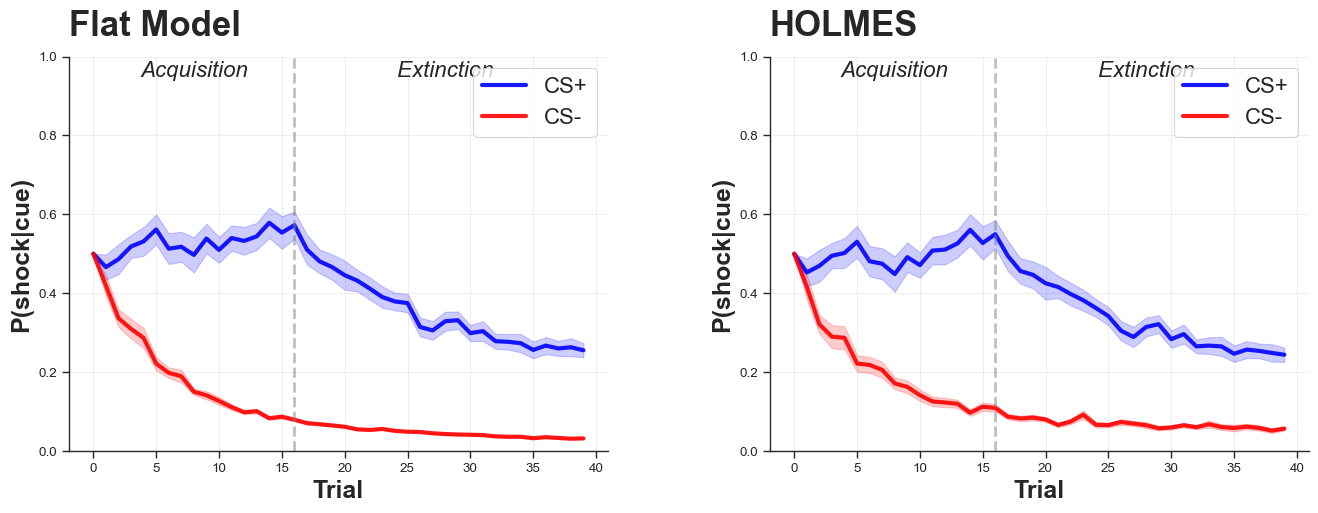

In [10]:

# Set publication-ready style
sns.set_context("paper", font_scale=1.1)
sns.set_style("ticks")

def plot_conditioned_response_cs_new(
    r_plus_all, r_minus_all, f, n_ext,
    title='Mean Conditioned Response',
    ax=None, 
    colors=None,
    show_legend=True,
    add_phase_labels=True,

):
    """
    Plot P(shock|CS+) and P(shock|CS−) as mean ± SEM across participants.
    Publication-ready styling with seaborn.

    Parameters
    ----------
    r_plus_all : list of arrays
        P(shock|CS+) for each participant/run
    r_minus_all : list of arrays
        P(shock|CS−) for each participant/run
    f : ndarray, shape (nFeatures, nTrials)
        Feature matrix with CS+ (row 0) and CS− (row 1)
    n_ext : int
        Trial where extinction begins
    title : str, optional
        Plot title
    ax : matplotlib Axes, optional
        Existing axes to plot on
    colors : list of str, optional
        Colors for [CS+, CS−]. Defaults to colorblind-friendly palette.
    show_legend : bool
        Whether to show legend
    add_phase_labels : bool
        Whether to add "Acquisition" and "Extinction" labels
    
    Returns
    -------
    ax : matplotlib Axes
    """
    
    # Default colorblind-friendly colors
    if colors is None:
        palette = sns.color_palette("colorblind")
        colors = [palette[0], palette[3]]  # Blue and red-orange
    
    # Aggregate across participants
    r_plus_arr = np.stack(r_plus_all)
    r_minus_arr = np.stack(r_minus_all)

    r_plus_mean = np.nanmean(r_plus_arr, axis=0)
    r_minus_mean = np.nanmean(r_minus_arr, axis=0)

    r_plus_err = stats.sem(r_plus_arr, nan_policy='omit', axis=0)
    r_minus_err = stats.sem(r_minus_arr, nan_policy='omit', axis=0)

    trials = np.arange(f.shape[1])
    csplus_mask = (f[0, :] == 1)
    csminus_mask = (f[1, :] == 1)

    # Create figure if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    # Plot CS+ with shaded error region
    ax.plot(trials[csplus_mask], r_plus_mean[csplus_mask],
            label='CS+', linewidth=3, color=colors[0], 
            marker='o', markersize=4, markevery=5, alpha=0.9)
    ax.fill_between(trials[csplus_mask],
                    r_plus_mean[csplus_mask] - r_plus_err[csplus_mask],
                    r_plus_mean[csplus_mask] + r_plus_err[csplus_mask],
                    color=colors[0], alpha=0.25, linewidth=0)

    # Plot CS− with shaded error region
    ax.plot(trials[csminus_mask], r_minus_mean[csminus_mask],
            label='CS−', linewidth=3, color=colors[1],
            marker='s', markersize=4, markevery=5, alpha=0.9)
    ax.fill_between(trials[csminus_mask],
                    r_minus_mean[csminus_mask] - r_minus_err[csminus_mask],
                    r_minus_mean[csminus_mask] + r_minus_err[csminus_mask],
                    color=colors[1], alpha=0.25, linewidth=0)

    # Add vertical line for extinction onset
    ax.axvline(n_ext, linestyle='--', color='gray', linewidth=2.5, 
               alpha=0.7, zorder=0)
    
    # Add phase labels
    if add_phase_labels:
        # Calculate middle points of each phase
        acq_mid = n_ext / 2
        ext_mid = n_ext + (len(trials) - n_ext) / 2
        
        ax.text(acq_mid, 1.05, 'Acquisition', 
               ha='center', va='bottom', fontsize = 16, 
               fontweight='bold', color='gray',
               transform=ax.get_xaxis_transform())
        ax.text(ext_mid, 1.05, 'Extinction',
               ha='center', va='bottom', fontsize = 16,
               fontweight='bold', color='gray',
               transform=ax.get_xaxis_transform())

    # Styling
    ax.set_xlabel('Trial', fontsize = 26, fontweight='bold')
    ax.set_ylabel('P(shock | cue)', fontsize = 26, fontweight='bold')
    ax.set_xlim(-1, len(trials))
    ax.set_ylim(-0.05, 1.15)
    ax.tick_params(axis='both', labelsize=15, width=1.5, length=6)
    
    # Remove top and right spines
    sns.despine(ax=ax)
    
    # Make remaining spines thicker
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(1.5)
    
    if title:
        ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
    
    if show_legend:
        ax.legend(frameon=True, fancybox=True, shadow=True, 
                 fontsize=15, loc='upper right',
                 framealpha=0.95)
    
    # Add grid for readability
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)
    
    return ax

# ============================================================
# CREATE FIGURE WITH STATS TABLE
# ============================================================

COLOR_FLAT = '#FFA500'
COLOR_HIER = '#7C3AED'

# Create figure with GridSpec for flexible layout
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 2, 0.8], hspace=0.35, wspace=0.3)

# ============================================================
# MIDDLE ROW: LEARNING CURVES
# ============================================================

# Extract learning curves
flat_stats = results_flat['statistics']
hier_stats = results_hier['statistics']

trials = np.arange(len(flat_stats['cs_plus']['mean']))
n_ext = results_flat['raw_data']['n_ext']

# Function to create individual panels
def create_learning_curve_panel(ax, stats, title, n_ext, trials):
    ax.set_title(title, fontsize=25, fontweight='bold', pad=15, loc='left')

    # Plot CS+ and CS-
    ax.plot(trials, stats['cs_plus']['mean'], 
            color='blue', linewidth=3, label='CS+', alpha=0.9)
    ax.fill_between(trials, 
                     stats['cs_plus']['mean'] - stats['cs_plus']['sem'],
                     stats['cs_plus']['mean'] + stats['cs_plus']['sem'],
                     color='blue', alpha=0.2)

    ax.plot(trials, stats['cs_minus']['mean'],
            color='red', linewidth=3, label='CS-', alpha=0.9)
    ax.fill_between(trials,
                     stats['cs_minus']['mean'] - stats['cs_minus']['sem'],
                     stats['cs_minus']['mean'] + stats['cs_minus']['sem'],
                     color='red', alpha=0.2)

    # Add acquisition/extinction divider
    ax.axvline(n_ext, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax.text(n_ext/2, 0.95, 'Acquisition', ha='center', transform=ax.get_xaxis_transform(),
            fontsize=16, style='italic')
    ax.text((n_ext + len(trials))/2, 0.95, 'Extinction', ha='center', 
            transform=ax.get_xaxis_transform(), fontsize=16, style='italic')

    ax.set_xlabel('Trial', fontsize=18, fontweight='bold')
    ax.set_ylabel('P(shock|cue)', fontsize=18, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.legend(fontsize=16, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create Flat Model Panel
ax_flat = fig.add_subplot(gs[1, 0])
create_learning_curve_panel(ax_flat, flat_stats, 'Flat Model', n_ext, trials)

# Create Hierarchical Model Panel
ax_hier = fig.add_subplot(gs[1, 1])
create_learning_curve_panel(ax_hier, hier_stats, 'HOLMES', n_ext, trials)

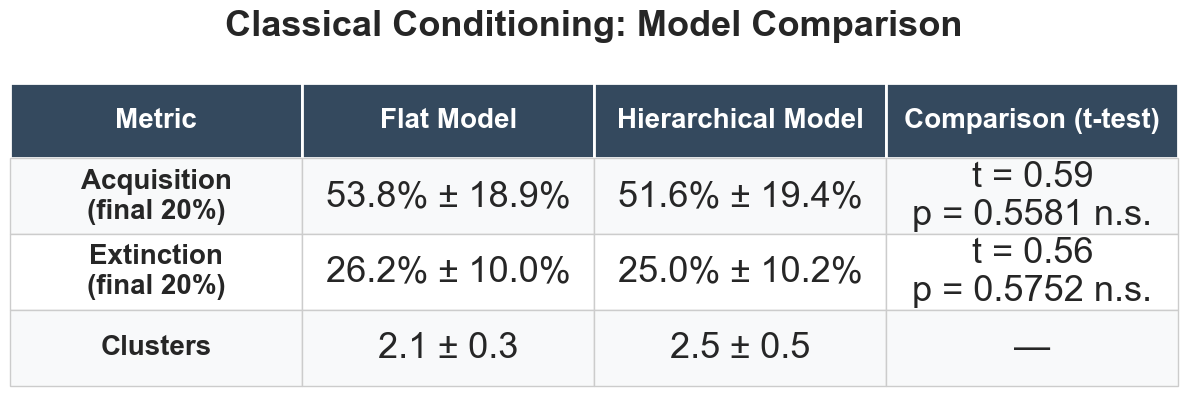

In [9]:
# ============================================================
# BOTTOM ROW: STATISTICS TABLE AS SEPARATE FIGURE
# ============================================================

fig_table = plt.figure(figsize=(12, 4))
ax_table = fig_table.add_subplot(111)
ax_table.axis('off')

# Prepare table data
flat_acq_mean = flat_stats['acquisition']['cs_plus_final_mean']
flat_acq_std = flat_stats['acquisition']['cs_plus_final_std']
hier_acq_mean = hier_stats['acquisition']['cs_plus_final_mean']
hier_acq_std = hier_stats['acquisition']['cs_plus_final_std']

flat_ext_mean = flat_stats['extinction']['cs_plus_final_mean']
flat_ext_std = flat_stats['extinction']['cs_plus_final_std']
hier_ext_mean = hier_stats['extinction']['cs_plus_final_mean']
hier_ext_std = hier_stats['extinction']['cs_plus_final_std']

flat_clusters = flat_stats['n_clusters']['mean']
flat_clusters_std = flat_stats['n_clusters']['std']
hier_clusters = hier_stats['n_clusters']['mean']
hier_clusters_std = hier_stats['n_clusters']['std']
tree_depth = hier_stats['tree_depth']['mean']

# Format p-values with significance markers
def format_pval(p):
    if p < 0.001:
        return f"{p:.4f}***"
    elif p < 0.01:
        return f"{p:.4f}**"
    elif p < 0.05:
        return f"{p:.4f}*"
    else:
        return f"{p:.4f} n.s."

table_data = [
    ['Metric', 'Flat Model', 'Hierarchical Model', 'Comparison (t-test)'],
    ['Acquisition\n(final 20%)',
     f'{flat_acq_mean:.1%} ± {flat_acq_std:.1%}',
     f'{hier_acq_mean:.1%} ± {hier_acq_std:.1%}',
     f't = {comparison["acquisition"]["t_statistic"]:.2f}\np = {format_pval(comparison["acquisition"]["p_value"])}'],
    ['Extinction\n(final 20%)',
     f'{flat_ext_mean:.1%} ± {flat_ext_std:.1%}',
     f'{hier_ext_mean:.1%} ± {hier_ext_std:.1%}',
     f't = {comparison["extinction"]["t_statistic"]:.2f}\np = {format_pval(comparison["extinction"]["p_value"])}'],
    ['Clusters',
     f'{flat_clusters:.1f} ± {flat_clusters_std:.1f}',
     f'{hier_clusters:.1f} ± {hier_clusters_std:.1f}',
     '—']
]

# Create table
table = ax_table.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1] 
)

# Style table
table.auto_set_font_size(False)
table.set_fontsize(26)
table.scale(2, 5)

# Header row styling
for i in range(4):
    cell = table[(0, i)]
    cell.set_facecolor('#34495E')
    cell.set_text_props(weight='bold', color='white', size=20)
    cell.set_edgecolor('white')
    cell.set_linewidth(2)

# Data rows styling
for row in range(1, 4):
    for col in range(4):
        cell = table[(row, col)]
        
        # Alternating row colors
        if row % 2 == 1:
            cell.set_facecolor('#F8F9FA')
        else:
            cell.set_facecolor('white')
        
        cell.set_edgecolor('#CCCCCC')
        cell.set_linewidth(1)
        
        # Bold first column (metric names)
        if col == 0:
            cell.set_text_props(weight='bold', size=20)
        
        # Highlight significant results in green
        if col == 3 and row < 3:  # Comparison column
            text = table_data[row][col]
            if '***' in text or '**' in text or '*' in text:
                cell.set_facecolor('#E8F5E9')  # Light green

# Add figure title
fig_table.suptitle('Classical Conditioning: Model Comparison', 
            fontsize = 26, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

